In [71]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [44]:
df = pd.read_csv(next(Path("../data").rglob("*.csv")), parse_dates=["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)

In [45]:
df["is_advisory"] = (df["flood_category"] != "Low Risk (Normal)").astype(int)

g = df.groupby("district")
df["advisory_48h"] = g["is_advisory"].shift(-2) 
df = df.dropna(subset=["advisory_48h"])

In [46]:
for lag in [1, 2, 3]:
    df[f"rain_lag{lag}"] = g["precipitation_sum"].shift(lag)

In [47]:
df["rain_7d"] = g["precipitation_sum"].transform(lambda s: s.rolling(7).sum())
df["soil_change_3d"] = df["soil_saturation_index"] - g["soil_saturation_index"].shift(3)
df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)

In [48]:
df["rain_3d"] = g["precipitation_sum"].transform(lambda s: s.rolling(3).sum())
df["rain_max_7d"] = g["precipitation_sum"].transform(lambda s: s.rolling(7).max())
df["wet_days_7d"] = g["precipitation_sum"].transform(lambda s: (s >= 1).rolling(7).sum())
df["soil_mean_7d"] = g["soil_saturation_index"].transform(lambda s: s.rolling(7).mean())


In [49]:
df = df.dropna().reset_index(drop=True)

In [50]:
df["advisory_48h"] = df["advisory_48h"].astype(int)
df.shape, df["advisory_48h"].mean()

((91125, 32), np.float64(0.07274622770919068))

In [51]:
num_features = ["precipitation_sum", "rain_48h", "rain_72h", "rain_7d",
                "rain_lag1", "rain_lag2", "rain_lag3",
                "soil_moisture_0_to_7cm_mean", "soil_moisture_7_to_28cm_mean",
                "soil_saturation_index", "soil_change_3d",
                "temperature_2m_max", "wind_speed_10m_max",
                "month_sin", "month_cos", "rain_3d", "rain_max_7d", "wet_days_7d", "soil_mean_7d"]
cat_features = ["district", "climatic_zone"]
target = "advisory_48h"

In [52]:
train = df[df["date"].dt.year <= 2021]
val   = df[df["date"].dt.year == 2022]
test  = df[df["date"].dt.year >= 2023]

In [53]:
X_train, y_train = train[num_features + cat_features], train[target]
X_val, y_val = val[num_features + cat_features], val[target]
X_test, y_test = test[num_features + cat_features], test[target]

In [54]:
print(len(X_train), len(X_val), len(X_test))
print(y_train.mean(), y_val.mean(), y_test.mean())

63775 9125 18225
0.06944727557820463 0.06761643835616438 0.08685871056241426


# PERSISTENCE BASELINE

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

In [56]:
def evaluate(y_true, y_pred, y_score=None):
    return{
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "pr_auc": average_precision_score(y_true, y_score if y_score is not None else y_pred),

    }

y_persistence = val["is_advisory"]
results = {"persistence_baseline": evaluate(y_val, y_persistence)}
pd.DataFrame(results).T.round(3)

,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152


## building an expanding-window CV split

In [59]:
# Sort chronologically (should already be sorted, but be explicit for CV)
train_sorted = train.sort_values("date").reset_index(drop=True)
X_train_cv = train_sorted[num_features + cat_features]
y_train_cv = train_sorted[target]

tscv = TimeSeriesSplit(n_splits=4)

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_cv)):
    tr_dates = train_sorted.loc[tr_idx, "date"]
    va_dates = train_sorted.loc[va_idx, "date"]
    print(f"fold {fold}: train {tr_dates.min().date()}–{tr_dates.max().date()} "
          f"({len(tr_idx)} rows) -> val {va_dates.min().date()}–{va_dates.max().date()} "
          f"({len(va_idx)} rows), pos rate {y_train_cv.iloc[va_idx].mean():.3f}")

fold 0: train 2015-01-07–2016-05-31 (12755 rows) -> val 2016-05-31–2017-10-23 (12755 rows), pos rate 0.041
fold 1: train 2015-01-07–2017-10-23 (25510 rows) -> val 2017-10-23–2019-03-17 (12755 rows), pos rate 0.082
fold 2: train 2015-01-07–2019-03-17 (38265 rows) -> val 2019-03-17–2020-08-08 (12755 rows), pos rate 0.065
fold 3: train 2015-01-07–2020-08-08 (51020 rows) -> val 2020-08-08–2021-12-31 (12755 rows), pos rate 0.087


In [60]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

logreg_pipe = Pipeline([
    ("pre", preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

### hyperparameter search for logistic regression

In [62]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],           # keep it simple; l1 needs a different solver
}

search = RandomizedSearchCV(
    logreg_pipe,
    param_distributions=param_dist,
    n_iter=6,                     # only 6 combos exist above, so this tries them all
    scoring="average_precision",  # PR-AUC — matches our imbalanced target
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train_cv, y_train_cv)
print("best C:", search.best_params_)
print("best CV PR-AUC:", search.best_score_)

c:\Users\Acer\Documents\GitHub\flood_risk_mlops\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


best C: {'model__penalty': 'l2', 'model__C': 0.1}
best CV PR-AUC: 0.3158136015646989


## evaluate the tuned model on val

In [63]:
best_logreg = search.best_estimator_
y_score = best_logreg.predict_proba(X_val)[:, 1]
y_pred = best_logreg.predict(X_val)

results["logistic_regression"] = evaluate(y_val, y_pred, y_score)
pd.DataFrame(results).T.round(3)

,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152
logistic_regression,0.194,0.806,0.313,0.296


PR-AUC nearly doubled (0.152 → 0.296). PR-AUC is threshold-independent, so this is the cleanest signal that the model has learned something real from the rainfall/soil trends that persistence ignores.
Recall jumped to 0.806 — it catches 81% of actual advisories, way more than persistence's 33%. That's class_weight="balanced" doing its job: it's aggressively flagging anything that looks risky.
But precision dropped to 0.194 — only 1 in 5 flagged days actually becomes an advisory. F1 (0.313) is a hair below persistence's 0.327, purely because F1 assumes precision and recall matter equally at the default 0.5 threshold, which they may not for this problem

For an early-warning system, missing a real flood (false negative) is usually far worse than one extra false alarm (false positive) — so high recall at the cost of precision is often the right call here.

## Random forest

In [65]:
rf_pipe = Pipeline(
    [
        ("pre", ColumnTransformer([
            ("num", "passthrough", num_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ])),
        ("model", RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1))
    ]
)

param_dist_rf = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [6, 10, 14, None],
    "model__min_samples_leaf": [1, 5, 20, 50],
    "model__max_features": ["sqrt", 0.5],
}

search_rf = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring="average_precision",
    cv=tscv,
    random_state=42,
    n_jobs=-1,

)

search_rf.fit(X_train_cv, y_train_cv)
print("best params: ", search_rf.best_params_)
print("best CV PPR-AUC: ", search_rf.best_score_)

best params:  {'model__n_estimators': 600, 'model__min_samples_leaf': 20, 'model__max_features': 'sqrt', 'model__max_depth': None}
best CV PPR-AUC:  0.3331585610672032


In [66]:
best_rf = search_rf.best_estimator_
y_score = best_rf.predict_proba(X_val)[:, 1]
y_pred = best_rf.predict(X_val)

results["random_forest"] = evaluate(y_val, y_pred, y_score)
pd.DataFrame(results).T.round(3)

,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152
logistic_regression,0.194,0.806,0.313,0.296
random_forest,0.249,0.648,0.359,0.307


## xgboost

In [69]:
# imbalance ratio for XGBoost's built-in weighting
scale_pos_weight = (y_train_cv == 0).sum() / (y_train_cv == 1).sum()

xgb_pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])),
    ("model", XGBClassifier(
        eval_metric="aucpr",
        random_state=42,
        n_jobs=1,
    )),
])

param_dist_xgb = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__min_child_weight": [1, 5, 10],
    "model__scale_pos_weight": [1, scale_pos_weight],   # try both weighted and unweighted
}

search_xgb = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="average_precision",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

search_xgb.fit(X_train_cv, y_train_cv)
print("best params:", search_xgb.best_params_)
print("best CV PR-AUC:", search_xgb.best_score_)

best params: {'model__subsample': 0.7, 'model__scale_pos_weight': np.float64(13.399412960036125), 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
best CV PR-AUC: 0.33554159470124334


In [70]:
best_xgb = search_xgb.best_estimator_
y_score = best_xgb.predict_proba(X_val)[:, 1]
y_pred = best_xgb.predict(X_val)

results["xgboost"] = evaluate(y_val, y_pred, y_score)
pd.DataFrame(results).T.round(3)

,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152
logistic_regression,0.194,0.806,0.313,0.296
random_forest,0.249,0.648,0.359,0.307
xgboost,0.206,0.802,0.328,0.316


## lightgbm

In [72]:
lgbm_pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])),
    ("model", LGBMClassifier(
        random_state=42,
        n_jobs=1,          # same fix as XGBoost — let RandomizedSearchCV parallelize, not the model
        verbose=-1,
    )),
])

param_dist_lgbm = {
    "model__n_estimators": [200, 400, 600],
    "model__num_leaves": [15, 31, 63],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__min_child_samples": [10, 20, 50],
    "model__scale_pos_weight": [1, scale_pos_weight],
}

search_lgbm = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring="average_precision",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
)

search_lgbm.fit(X_train_cv, y_train_cv)
print("best params:", search_lgbm.best_params_)
print("best CV PR-AUC:", search_lgbm.best_score_)

best params: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__num_leaves': 15, 'model__n_estimators': 600, 'model__min_child_samples': 20, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
best CV PR-AUC: 0.3336501583172431


In [73]:
best_lgbm = search_lgbm.best_estimator_
y_score = best_lgbm.predict_proba(X_val)[:, 1]
y_pred = best_lgbm.predict(X_val)

results["lightgbm"] = evaluate(y_val, y_pred, y_score)
pd.DataFrame(results).T.round(3)

,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152
logistic_regression,0.194,0.806,0.313,0.296
random_forest,0.249,0.648,0.359,0.307
xgboost,0.206,0.802,0.328,0.316
lightgbm,0.667,0.042,0.079,0.318


## feature importance

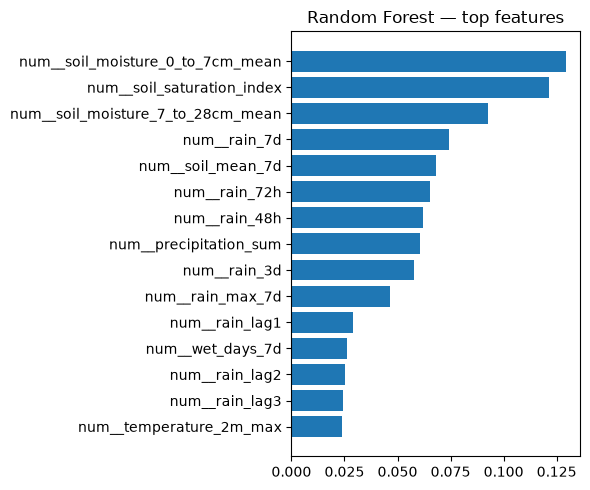

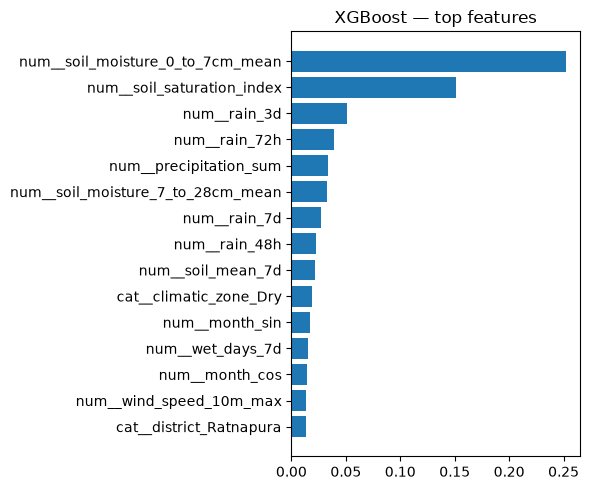

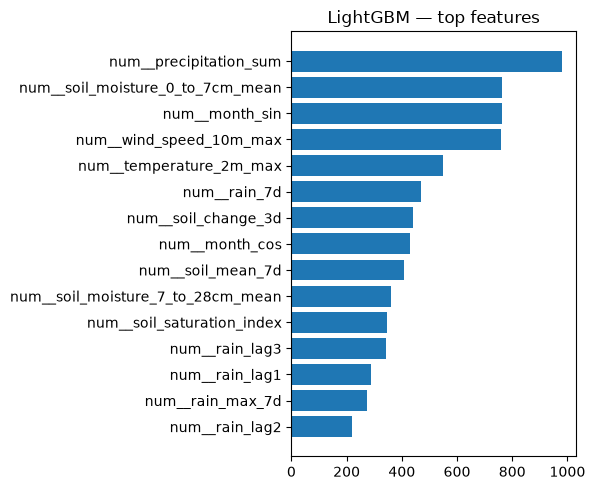

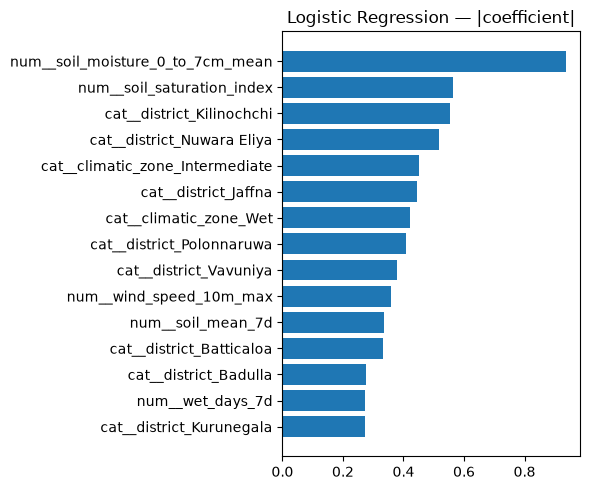

In [ ]:
import matplotlib.pyplot as plt

def get_feature_names(pipe):
    return pipe.named_steps["pre"].get_feature_names_out()

def plot_importance(pipe, title, top_n=15):
    names = get_feature_names(pipe)
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:  # logistic regression: use absolute coefficient size
        importances = np.abs(model.coef_[0])
    order = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(6, 5))
    plt.barh(range(len(order)), importances[order])
    plt.yticks(range(len(order)), [names[i] for i in order])
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_importance(best_rf, "Random Forest — top features")
plot_importance(best_xgb, "XGBoost — top features")
plot_importance(best_lgbm, "LightGBM — top features")
plot_importance(best_logreg, "Logistic Regression — |coefficient|")

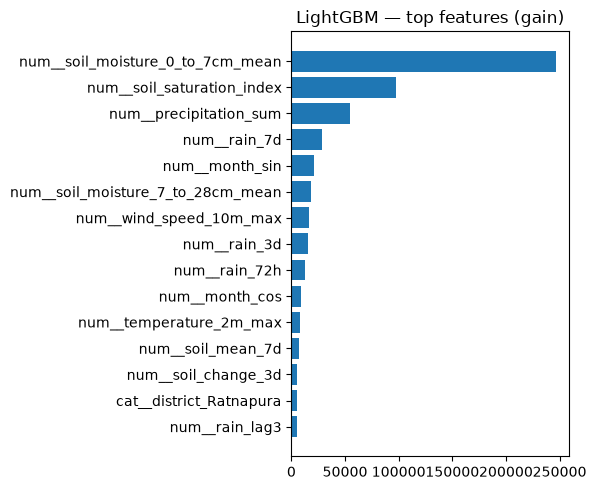

In [75]:
lgbm_model = best_lgbm.named_steps["model"]
names = get_feature_names(best_lgbm)
gains = lgbm_model.booster_.feature_importance(importance_type="gain")

order = np.argsort(gains)[-15:]
plt.figure(figsize=(6, 5))
plt.barh(range(len(order)), gains[order])
plt.yticks(range(len(order)), [names[i] for i in order])
plt.title("LightGBM — top features (gain)")
plt.tight_layout()
plt.show()

## threshold tuninng

In [77]:
from sklearn.metrics import precision_recall_curve, fbeta_score

def best_threshold(y_true, y_score, beta=1.0):
    prec, rec, thresh = precision_recall_curve(y_true, y_score)
    f_scores = (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-9)
    best_idx = np.nanargmax(f_scores[:-1])  # last point has no matching threshold
    return thresh[best_idx], prec[best_idx], rec[best_idx], f_scores[best_idx]

for name, model in [("logistic_regression", best_logreg), ("random_forest", best_rf),
                     ("xgboost", best_xgb), ("lightgbm", best_lgbm)]:
    y_score = model.predict_proba(X_val)[:, 1]
    t, p, r, f = best_threshold(y_val, y_score, beta=1.0)
    print(f"{name:20s} threshold={t:.3f}  precision={p:.3f}  recall={r:.3f}  f1={f:.3f}")

logistic_regression  threshold=0.679  precision=0.265  recall=0.626  f1=0.373
random_forest        threshold=0.581  precision=0.280  recall=0.561  f1=0.374
xgboost              threshold=0.718  precision=0.303  recall=0.556  f1=0.392
lightgbm             threshold=0.158  precision=0.290  recall=0.587  f1=0.388


## accuracy score

In [78]:
from sklearn.metrics import accuracy_score

thresholds = {
    "logistic_regression": (best_logreg, 0.679),
    "random_forest": (best_rf, 0.581),
    "xgboost": (best_xgb, 0.718),
    "lightgbm": (best_lgbm, 0.158),
}

# trivial baseline for comparison
print(f"{'always_predict_no_flood':22s} accuracy={1 - y_val.mean():.3f}")

for name, (model, t) in thresholds.items():
    y_score = model.predict_proba(X_val)[:, 1]
    y_pred_t = (y_score >= t).astype(int)
    acc = accuracy_score(y_val, y_pred_t)
    print(f"{name:22s} accuracy={acc:.3f}")

always_predict_no_flood accuracy=0.932
logistic_regression    accuracy=0.858
random_forest          accuracy=0.873
xgboost                accuracy=0.884
lightgbm               accuracy=0.874


In [79]:
def grouped_importance(pipe, prefix="cat__district_"):
    names = get_feature_names(pipe)
    model = pipe.named_steps["model"]
    importances = model.feature_importances_ if hasattr(model, "feature_importances_") \
                  else np.abs(model.coef_[0])
    total = sum(imp for n, imp in zip(names, importances) if n.startswith(prefix))
    print(f"{prefix} total importance: {total:.4f}  (out of {importances.sum():.4f})")

grouped_importance(best_xgb, "cat__district_")
grouped_importance(best_xgb, "cat__climatic_zone_")
grouped_importance(best_rf, "cat__district_")

cat__district_ total importance: 0.2050  (out of 1.0000)
cat__climatic_zone_ total importance: 0.0398  (out of 1.0000)
cat__district_ total importance: 0.0112  (out of 1.0000)


In [81]:
from sklearn.model_selection import cross_val_score
weak_features = ["rain_lag2", "rain_lag3", "temperature_2m_max", "wind_speed_10m_max"]
num_features_trimmed = [f for f in num_features if f not in weak_features]

xgb_trimmed_pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", num_features_trimmed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ])),
    ("model", XGBClassifier(**{k.replace("model__", ""): v
                                for k, v in search_xgb.best_params_.items()},
                             eval_metric="aucpr", random_state=42, n_jobs=1)),
])

X_train_cv_trimmed = train_sorted[num_features_trimmed + cat_features]

scores_full = cross_val_score(best_xgb, X_train_cv, y_train_cv, cv=tscv, scoring="average_precision", n_jobs=-1)
scores_trimmed = cross_val_score(xgb_trimmed_pipe, X_train_cv_trimmed, y_train_cv, cv=tscv, scoring="average_precision", n_jobs=-1)

print("full features   :", scores_full.mean().round(4), scores_full.round(3))
print("trimmed features :", scores_trimmed.mean().round(4), scores_trimmed.round(3))

full features   : 0.3355 [0.293 0.391 0.364 0.295]
trimmed features : 0.3204 [0.253 0.391 0.35  0.288]


conclusion: keep all the features

In [82]:
final_model = best_xgb
final_threshold = 0.718

y_test_score = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_score >= final_threshold).astype(int)

test_results = evaluate(y_test, y_test_pred, y_test_score)
print(test_results)

results["xgboost_test"] = test_results
pd.DataFrame(results).T.round(3)

{'precision': 0.36629526462395545, 'recall': 0.6645609602021478, 'f1': 0.4722783389450056, 'pr_auc': 0.42215109415368574}


,precision,recall,f1,pr_auc
persistence_baseline,0.326,0.327,0.327,0.152
logistic_regression,0.194,0.806,0.313,0.296
random_forest,0.249,0.648,0.359,0.307
xgboost,0.206,0.802,0.328,0.316
lightgbm,0.667,0.042,0.079,0.318
xgboost_test,0.366,0.665,0.472,0.422
